# Favorita Grocery Sales: Time-Series EDA

## 1. Objective

This notebook explores the Favorita Grocery Sales forecasting problem before feature engineering or model development. The forecasting grain is **date + store_nbr + family**, and the target variable is **sales**. Based on raw-data profiling, the final test horizon is **2017-08-16 through 2017-08-31**.

The analyses examine temporal patterns, cross-sectional differences, the target distribution, promotions, and supporting variables. No model training or feature preparation is performed.

The training CSV contains about three million rows. Avoid repeatedly loading it or making full-size copies. This notebook loads it once through the project loader and reuses smaller aggregates. The visualization cells require `matplotlib` and `seaborn`; neither is currently installed in this environment. Install them in the project environment before running those cells. No packages are installed by this notebook.

## 2. Dataset Overview

Load each raw dataset once using the existing loader. Train and test are retained for this exploratory session; supporting tables are also small enough to inspect directly.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'pyproject.toml').is_file()
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

loader = importlib.import_module('forecasting.data.loader')

train = loader.load_train()
test = loader.load_test()
stores = loader.load_stores()
oil = loader.load_oil()
holidays_events = loader.load_holidays_events()
transactions = loader.load_transactions()

In [2]:
dataset_frames = {
    'train': train,
    'test': test,
    'stores': stores,
    'oil': oil,
    'holidays_events': holidays_events,
    'transactions': transactions,
}
pd.DataFrame(
    {name: {'rows': len(frame), 'columns': len(frame.columns)}
     for name, frame in dataset_frames.items()}
).T

,rows,columns
train,3000888,6
test,28512,5
stores,54,5
oil,1218,2
holidays_events,350,6
transactions,83488,3


In [3]:
stores.head(), oil.head(), holidays_events.head(), transactions.head()

(   store_nbr           city                           state type  cluster
 0          1          Quito                       Pichincha    D       13
 1          2          Quito                       Pichincha    D       13
 2          3          Quito                       Pichincha    D        8
 3          4          Quito                       Pichincha    D        9
 4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4,
          date  dcoilwtico
 0  2013-01-01         NaN
 1  2013-01-02       93.14
 2  2013-01-03       92.97
 3  2013-01-04       93.12
 4  2013-01-07       93.20,
          date     type    locale locale_name                    description  \
 0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
 1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
 2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
 3  2012-04-14  Holiday     Local    Libertad      Cantonizacion d

## 3. Date Preparation

Parse dates in the in-memory training and test frames without changing any raw files. Calendar fields are derived on the compact daily aggregate, avoiding extra full-sized train copies.

In [4]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
train[['date', 'store_nbr', 'family', 'sales', 'onpromotion']].head()

,date,store_nbr,family,sales,onpromotion
0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,2013-01-01,1,BABY CARE,0.0,0
2,2013-01-01,1,BEAUTY,0.0,0
3,2013-01-01,1,BEVERAGES,0.0,0
4,2013-01-01,1,BOOKS,0.0,0


## 4. Overall Sales Trend

Aggregate sales by date and inspect the daily series for its long-term trend, structural changes, unusual periods, and major spikes or drops. This view does not explain causes by itself.

In [5]:
daily_sales = (
    train.groupby('date', as_index=False)['sales']
    .sum()
)
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['day_of_month'] = daily_sales['date'].dt.day
daily_sales.head()

,date,sales,year,month,day_of_week,day_of_month
0,2013-01-01,2511.618999,2013,1,1,1
1,2013-01-02,496092.417944,2013,1,2,2
2,2013-01-03,361461.231124,2013,1,3,3
3,2013-01-04,354459.677093,2013,1,4,4
4,2013-01-05,477350.121229,2013,1,5,5


In [6]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ImportError:
    plt = None
    sns = None
    print('Install matplotlib and seaborn before running visualization cells.')

def require_plotting():
    if plt is None or sns is None:
        raise ImportError('Install matplotlib and seaborn to run visualization cells.')

Matplotlib is building the font cache; this may take a moment.


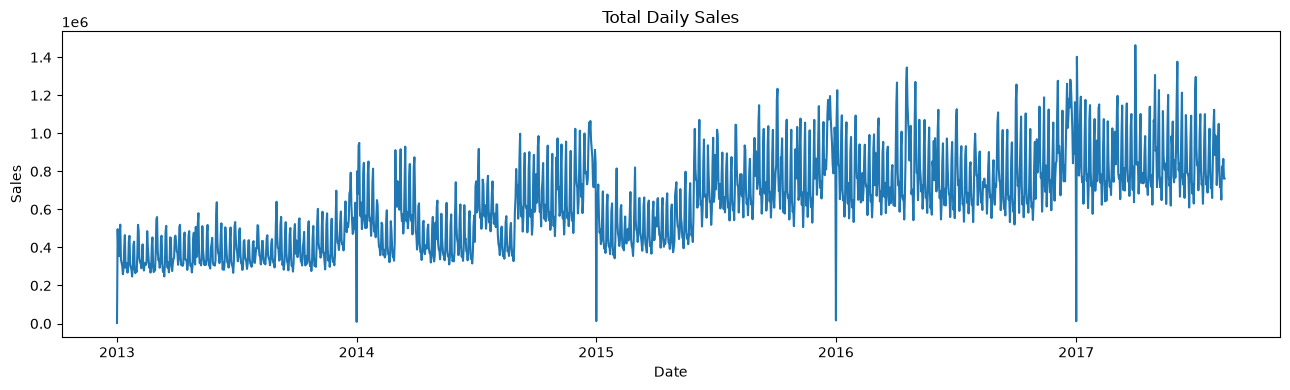

In [7]:
require_plotting()
fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(data=daily_sales, x='date', y='sales', ax=ax)
ax.set(title='Total Daily Sales', xlabel='Date', ylabel='Sales')
fig.tight_layout()

## 5. Monthly Trend

Monthly totals smooth some day-to-day variation and help expose longer-term trend and seasonality. The monthly aggregate is derived from the daily result, so train is not grouped again.

In [8]:
monthly_sales = (
    daily_sales.set_index('date')['sales']
    .resample('MS')
    .sum()
    .rename('sales')
    .reset_index()
)
monthly_sales.head()

,date,sales
0,2013-01-01,1.032762e+07
1,2013-02-01,9.658960e+06
2,2013-03-01,1.142850e+07
3,2013-04-01,1.099346e+07
4,2013-05-01,1.159770e+07


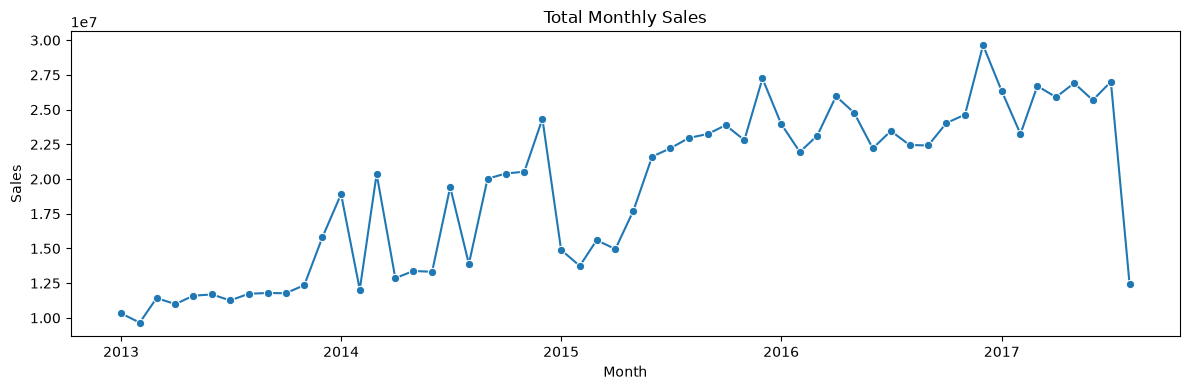

In [9]:
require_plotting()
fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=monthly_sales, x='date', y='sales', marker='o', ax=ax)
ax.set(title='Total Monthly Sales', xlabel='Month', ylabel='Sales')
fig.tight_layout()

## 6. Day-of-Week Pattern

Compare average total daily sales by weekday. The data, rather than an assumption about weekends, should determine whether weekday differences are present.

In [10]:
weekday_names = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]
weekday_sales = (
    daily_sales.groupby('day_of_week')['sales']
    .mean()
    .reindex(range(7))
    .rename('average_sales')
    .rename_axis('day_of_week')
    .reset_index()
)
weekday_sales['weekday'] = weekday_sales['day_of_week'].map(
    dict(enumerate(weekday_names))
)
weekday_sales

,day_of_week,average_sales,weekday
0,0,617542.713052,Monday
1,1,569926.087922,Tuesday
2,2,593244.553472,Wednesday
3,3,505269.201115,Thursday
4,4,579574.361085,Friday
5,5,772205.593943,Saturday
6,6,825218.121579,Sunday


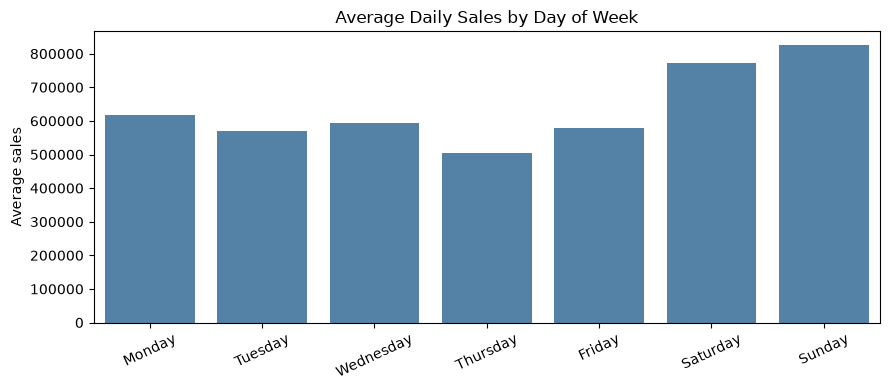

In [11]:
require_plotting()
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=weekday_sales, x='weekday', y='average_sales', color='steelblue', ax=ax
)
ax.set(title='Average Daily Sales by Day of Week', xlabel='', ylabel='Average sales')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()

## 7. Year/Month Seasonality

Compare monthly average daily sales across years. Averaging daily totals within each month makes months of different lengths more comparable than summing their totals.

In [12]:
year_month_sales = (
    daily_sales.groupby(['year', 'month'], as_index=False)['sales']
    .mean()
    .rename(columns={'sales': 'average_daily_sales'})
)
year_month_sales.pivot(index='month', columns='year', values='average_daily_sales')

year,2013,2014,2015,2016,2017
month,,,,,
1,333149.185062,610052.925852,480545.872813,773477.576949,849295.481797
2,344962.849194,429941.165499,490799.851728,756807.200035,830361.156248
3,368661.194758,656954.323112,503180.887689,746186.480123,861419.925512
4,366448.824600,428708.368572,498502.272359,865434.170065,863176.949652
5,374119.484098,431605.976168,571947.362720,799336.524523,868124.104858
6,389644.802075,443998.605767,720512.011708,740307.286013,856094.070833
7,363141.955086,626512.614317,716439.323830,756860.401068,871337.985995
8,378638.352241,447908.916744,740763.685203,724271.429610,828888.196052
9,393097.774396,667413.870460,774696.082597,747248.269900,NaN


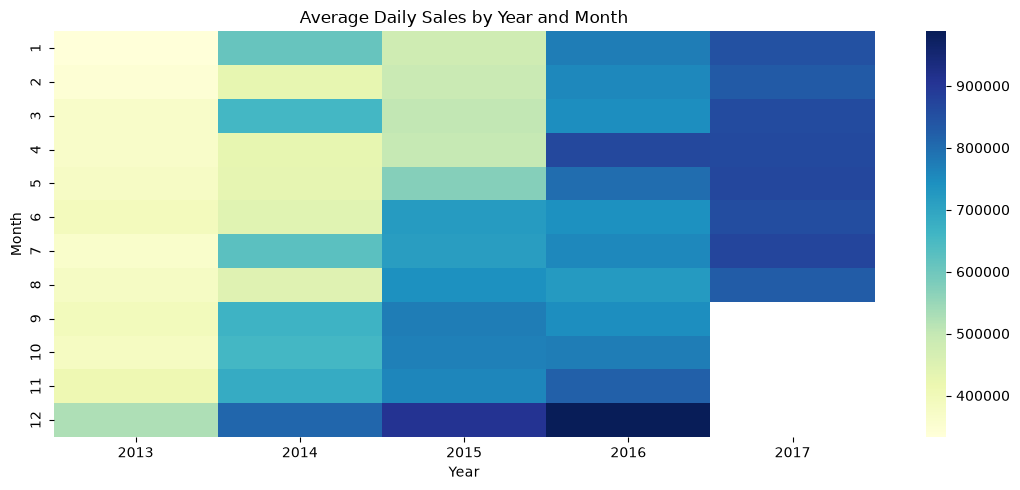

In [13]:
require_plotting()
seasonality = year_month_sales.pivot(
    index='month', columns='year', values='average_daily_sales'
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(seasonality, cmap='YlGnBu', annot=False, ax=ax)
ax.set(title='Average Daily Sales by Year and Month', xlabel='Year', ylabel='Month')
fig.tight_layout()

## 8. Store-Level Analysis

Compare total observed sales by store. The table and chart describe differences in the training period; they do not label stores as good or bad.

In [14]:
store_sales = train.groupby('store_nbr', as_index=False)['sales'].sum()
store_sales = store_sales.sort_values('sales', ascending=False)
display(store_sales.head(5).assign(relative_rank='Highest'))
display(store_sales.tail(5).sort_values('sales').assign(relative_rank='Lowest'))

,store_nbr,sales,relative_rank
43,44,6.208755e+07,Highest
44,45,5.449801e+07,Highest
46,47,5.094831e+07,Highest
2,3,5.048191e+07,Highest
48,49,4.342010e+07,Highest


,store_nbr,sales,relative_rank
51,52,2.696170e+06,Lowest
21,22,4.090202e+06,Lowest
31,32,5.951796e+06,Lowest
29,30,7.382074e+06,Lowest
34,35,7.676679e+06,Lowest


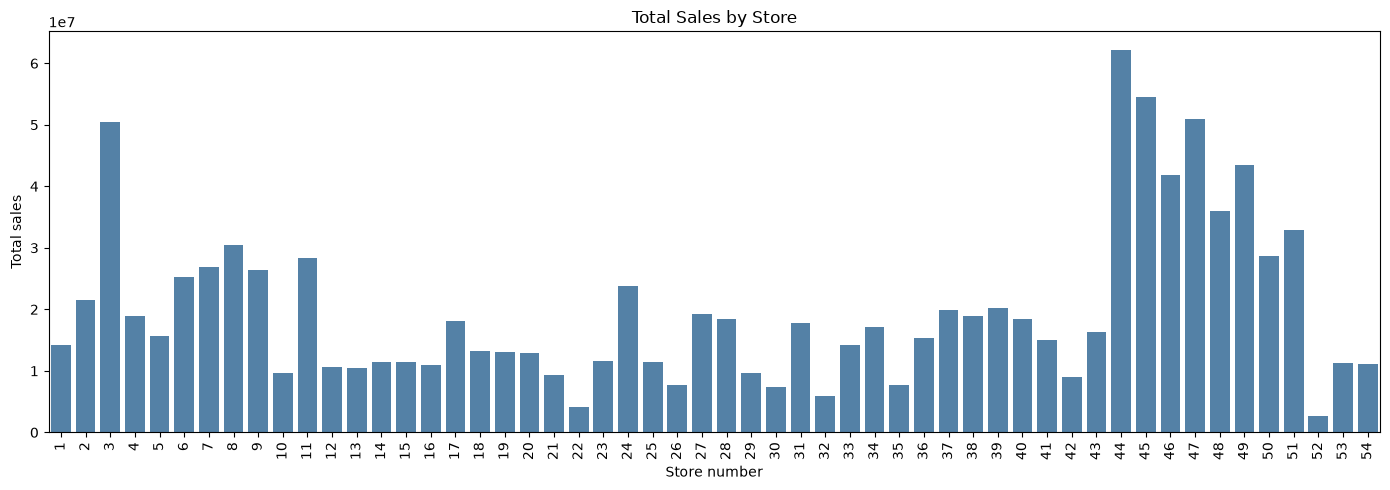

In [15]:
require_plotting()
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=store_sales, x='store_nbr', y='sales', color='steelblue', ax=ax)
ax.set(title='Total Sales by Store', xlabel='Store number', ylabel='Total sales')
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()

## 9. Family-Level Analysis

Compare total sales across product families and display the highest and lowest observed totals.

In [16]:
family_sales = train.groupby('family', as_index=False)['sales'].sum()
family_sales = family_sales.sort_values('sales', ascending=False)
display(family_sales.head(5))
display(family_sales.tail(5).sort_values('sales'))

,family,sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07


,family,sales
4,BOOKS,6438.0
1,BABY CARE,10051.0
17,HOME APPLIANCES,41601.0
14,HARDWARE,103470.0
23,MAGAZINES,266359.0


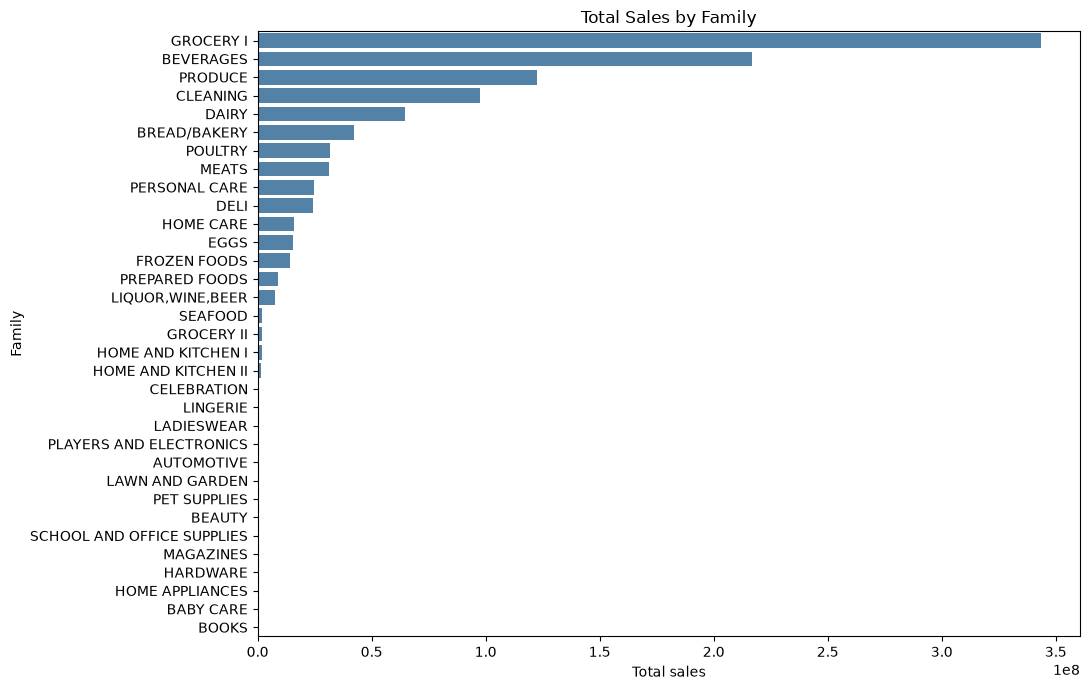

In [17]:
require_plotting()
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=family_sales, y='family', x='sales', color='steelblue', ax=ax)
ax.set(title='Total Sales by Family', xlabel='Total sales', ylabel='Family')
fig.tight_layout()

## 10. Sales Distribution

Inspect the raw target distribution, including zero sales and selected quantiles. Keep all observations, including extreme values; no target transformation is applied here.

In [18]:
sales_quantiles = train['sales'].quantile([0.50, 0.90, 0.95, 0.99]).rename('sales')
zero_sales_proportion = train['sales'].eq(0).mean()
print(f'Zero-sales proportion: {zero_sales_proportion:.2%}')
sales_quantiles

Zero-sales proportion: 31.30%


0.50      11.0
0.90     867.0
0.95    1965.0
0.99    5507.0
Name: sales, dtype: float64

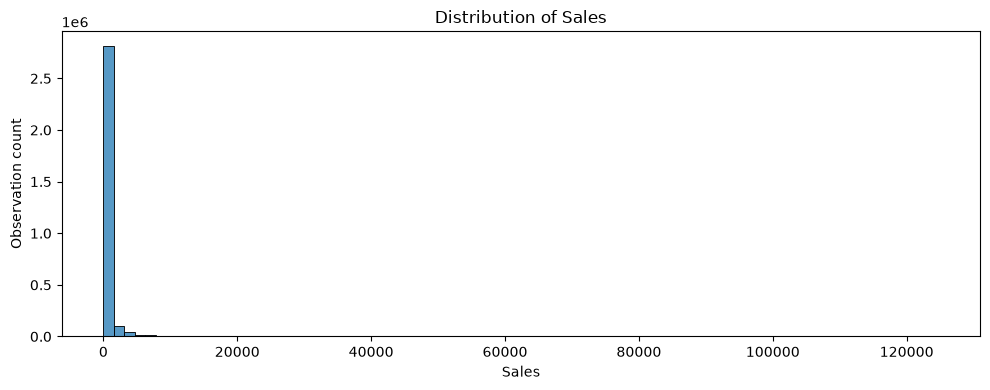

In [19]:
require_plotting()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=train, x='sales', bins=80, ax=ax)
ax.set(title='Distribution of Sales', xlabel='Sales', ylabel='Observation count')
fig.tight_layout()

## 11. Promotion Analysis

Compare observed sales when `onpromotion` is zero versus greater than zero. This is descriptive association, not evidence that promotion caused a sales change.

In [20]:
promotion_summary = (
    train.groupby(train['onpromotion'].gt(0).rename('has_promotion'))['sales']
    .agg(observations='size', average_sales='mean', median_sales='median')
)
promotion_summary['observation_proportion'] = (
    promotion_summary['observations'] / len(train)
)
promotion_summary

,observations,average_sales,median_sales,observation_proportion
has_promotion,,,,
False,2389559,158.246681,3.0,0.796284
True,611329,1137.693730,373.0,0.203716


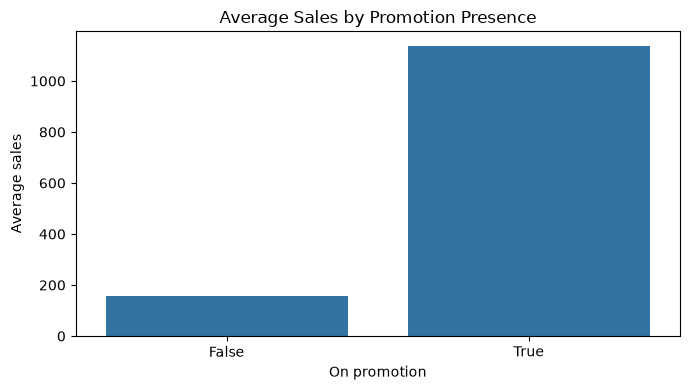

In [21]:
require_plotting()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=train,
    x=train['onpromotion'].gt(0),
    y='sales',
    estimator='mean',
    errorbar=None,
    ax=ax,
)
ax.set(
    title='Average Sales by Promotion Presence',
    xlabel='On promotion',
    ylabel='Average sales',
)
fig.tight_layout()

## 12. Supporting Variables

Inspect oil prices, transaction counts, and holiday/event counts over time. These are separate views; this notebook does not merge them into a modeling table.

In [22]:
oil['date'] = pd.to_datetime(oil['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
holidays_events['date'] = pd.to_datetime(holidays_events['date'])
daily_transactions = transactions.groupby('date', as_index=False)['transactions'].sum()
daily_events = (
    holidays_events.groupby('date').size().rename('event_count').reset_index()
)
oil.head(), daily_transactions.head(), daily_events.head()

(        date  dcoilwtico
 0 2013-01-01         NaN
 1 2013-01-02       93.14
 2 2013-01-03       92.97
 3 2013-01-04       93.12
 4 2013-01-07       93.20,
         date  transactions
 0 2013-01-01           770
 1 2013-01-02         93215
 2 2013-01-03         78504
 3 2013-01-04         78494
 4 2013-01-05         93573,
         date  event_count
 0 2012-03-02            1
 1 2012-04-01            1
 2 2012-04-12            1
 3 2012-04-14            1
 4 2012-04-21            1)

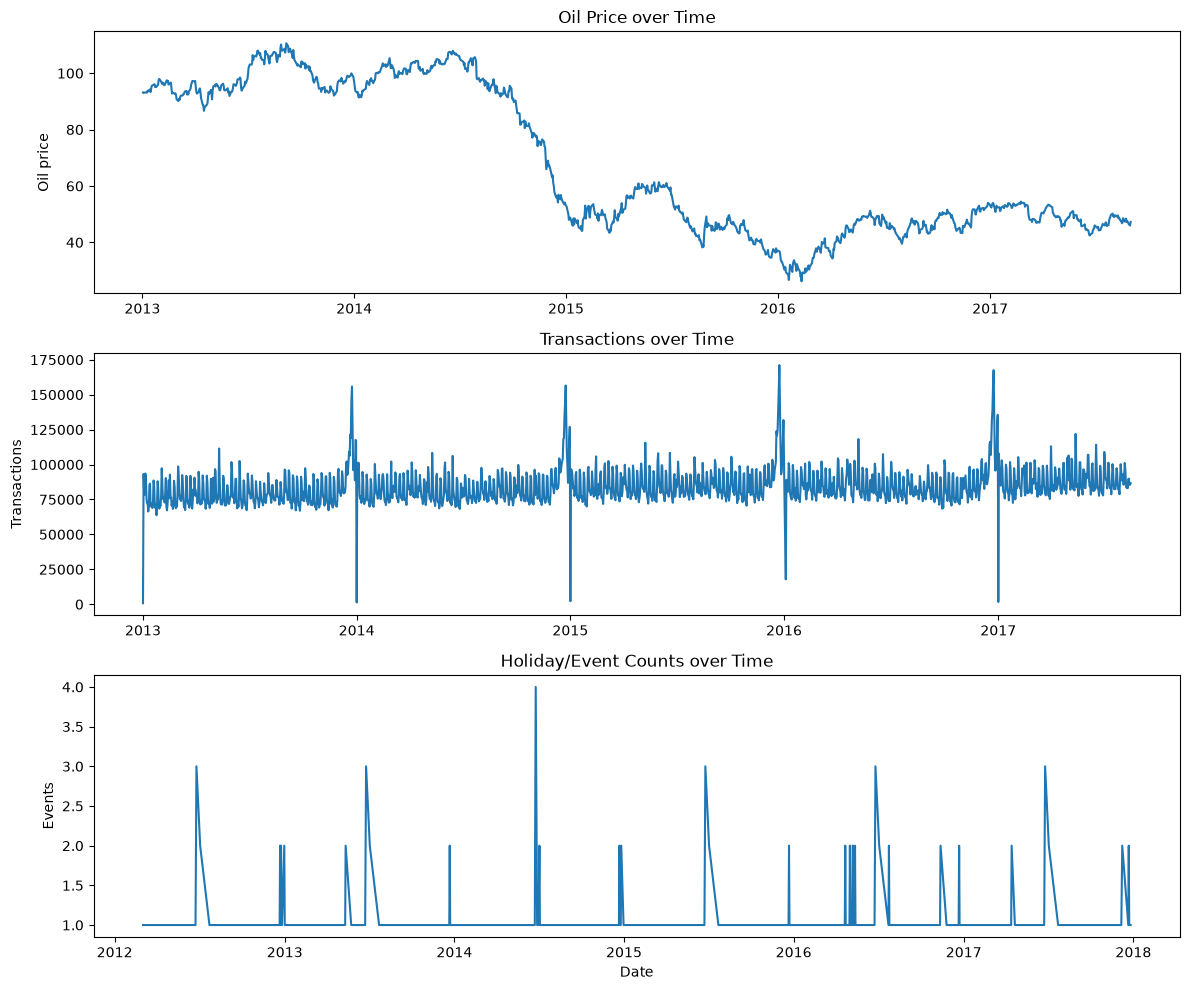

In [23]:
require_plotting()
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
sns.lineplot(data=oil, x='date', y='dcoilwtico', ax=axes[0])
axes[0].set(title='Oil Price over Time', xlabel='', ylabel='Oil price')
sns.lineplot(data=daily_transactions, x='date', y='transactions', ax=axes[1])
axes[1].set(title='Transactions over Time', xlabel='', ylabel='Transactions')
sns.lineplot(data=daily_events, x='date', y='event_count', ax=axes[2])
axes[2].set(title='Holiday/Event Counts over Time', xlabel='Date', ylabel='Events')
fig.tight_layout()

## 13. Forecast-Time Data Availability

Current availability notes, based on the provided files:

- **date:** present in the test rows and therefore known for the forecast horizon.
- **store_nbr:** present in test and known for each forecast row.
- **family:** present in test and known for each forecast row.
- **onpromotion:** present in test; the values are available in this dataset, though their provenance and timing should be confirmed before modeling.
- **sales:** the future target is unknown for the forecast horizon.
- **transactions:** this table contains observed transaction counts; availability for future forecast dates needs verification.
- **oil:** historical prices are present; future availability and date alignment need verification.
- **holidays/events:** event dates may be known in advance, but the completeness and advance availability of this table should be confirmed.

No assumptions are made here that supporting variables are available at prediction time.

## 14. EDA Findings / Questions for Modeling

Review the tables and figures after executing the notebook, then record observed patterns here. No findings are pre-filled. Questions to carry forward include:

- Which trend or calendar patterns appear stable across years?
- How much variation exists between stores and product families?
- How do zero values and the upper tail affect the choice of evaluation summaries?
- Which supporting variables can be verified as available at each forecast date?
- Are any observed spikes or changes explained by data coverage or known calendar events?

This notebook stops at exploration: it does not create modeling features, split data, train models, or generate forecasts.